In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import tqdm
import os
import wandb

# --- Code Explanation and Task Outline ---
# This cell contains a PyTorch implementation of a Conditional Generative Adversarial Network (CGAN).
# It consists of a Generator (G) that creates images from random noise and a Discriminator (D)
# that tries to distinguish between real and generated images, both conditioned on a class label.
#
# Task 1: Run this code as is to train the Vanilla GAN using Binary Cross-Entropy (BCE) loss.
#         Observe the generated samples and loss curves.
#
# Task 2: Modify this code to use 'Logistic loss' as described in Brandon Amos's blog.
#         You might need to adjust network architectures slightly. Run the modified code
#         for 5, 10, and 50 epochs and compare the results with Task 1.
#
# Task 3: Modify the GAN to be a Conditional GAN (CGAN). Both the Generator and Discriminator
#         will now take an additional input: the class label (0-9). The training loop will be
#         updated to pass these labels, and the `save_sample` function will be modified to
#         generate images for specific target digits.
# -----------------------------------------

# Hyperparameters
mb_size = 64
Z_dim = 1000 # Noise dimension
y_dim = 10   # Number of classes (digits 0-9)
h_dim = 128  # Hidden dimension
lr = 1e-3

# Load MNIST data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)) # Flatten the 28x28 image to 784
])
train_dataset = datasets.MNIST(root='../MNIST', train=True, transform=transform,
                               download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True)
X_dim = 784 # 28 x 28

# Xavier Initialization
def xavier_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Generator for CGAN
class Generator(nn.Module):
    def __init__(self, z_dim, y_dim, h_dim, x_dim):
        super(Generator, self).__init__()
        # Input is noise (z) concatenated with one-hot encoded label (y)
        self.fc1 = nn.Linear(z_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, x_dim)
        self.apply(xavier_init)

    def forward(self, z, y):
        # Concatenate noise and label
        h = F.relu(self.fc1(torch.cat([z, y], 1)))
        out = torch.sigmoid(self.fc2(h))
        return out

# Discriminator for CGAN
class Discriminator(nn.Module):
    def __init__(self, x_dim, y_dim, h_dim):
        super(Discriminator, self).__init__()
        # Input is image (x) concatenated with one-hot encoded label (y)
        self.fc1 = nn.Linear(x_dim + y_dim, h_dim)
        self.fc2 = nn.Linear(h_dim, 1)
        self.apply(xavier_init)

    def forward(self, x, y):
        # Concatenate image and label
        h = F.relu(self.fc1(torch.cat([x, y], 1)))
        # For Logistic Loss, we return logits
        out = self.fc2(h)
        return out

# Training for CGAN
def cGANTraining(G, D, loss_fn, train_loader, y_dim):
    G.train()
    D.train()
    D_loss_real_total = 0
    D_loss_fake_total = 0
    G_loss_total = 0
    t = tqdm.tqdm(train_loader)
    for it, (X_real, labels) in enumerate(t):
        # Prepare real data and one-hot encode labels
        X_real = X_real.float().to(device)
        y_onehot_real = F.one_hot(labels, num_classes=y_dim).float().to(device)

        # Sample noise and labels for generator
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        # For generator's output to be judged by D, D needs the real label
        # For generator's input, G needs a random label or the same as real batch
        # Here, we use the real labels for consistency in D's evaluation of fake
        # and for G's initial training step for that batch.
        y_gen = F.one_hot(torch.randint(0, y_dim, (X_real.size(0),)), num_classes=y_dim).float().to(device)

        ones_label = torch.ones(X_real.size(0), 1).to(device)
        zeros_label = torch.zeros(X_real.size(0), 1).to(device)

        # ================= Train Discriminator =================
        # Train D with real data
        D_real = D(X_real, y_onehot_real)
        D_loss_real = loss_fn(D_real, ones_label)

        # Train D with fake data
        G_sample = G(z, y_onehot_real) # Generator conditioned on real labels
        D_fake = D(G_sample.detach(), y_onehot_real)
        D_loss_fake = loss_fn(D_fake, zeros_label)

        D_loss = D_loss_real + D_loss_fake
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ================= Train Generator ====================
        z = torch.randn(X_real.size(0), Z_dim).to(device)
        y_gen = F.one_hot(torch.randint(0, y_dim, (X_real.size(0),)), num_classes=y_dim).float().to(device)

        G_sample = G(z, y_gen)
        D_fake = D(G_sample, y_gen) # Discriminator evaluates fake samples conditioned on generator's chosen labels
        G_loss = loss_fn(D_fake, ones_label)
        G_loss_total += G_loss.item()

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # ================= Logging =================
        D_loss_real_avg = D_loss_real_total / (it + 1)
        D_loss_fake_avg = D_loss_fake_total / (it + 1)
        D_loss_avg = D_loss_real_avg + D_loss_fake_avg
        G_loss_avg = G_loss_total / (it + 1)
        wandb.log({
            "D_loss_real": D_loss_real_avg,
            "D_loss_fake": D_loss_fake_avg,
            "D_loss": D_loss_avg,
            "G_loss": G_loss_avg
        })
    return G, D, G_loss_avg, D_loss_avg

def save_sample(G, epoch, y_dim, Z_dim):
    out_dir = "out_conditional_GAN"
    G.eval()
    with torch.no_grad():
        # Generate one sample for each digit 0-9
        z = torch.randn(y_dim, Z_dim).to(device)
        # Create one-hot encoded labels for digits 0-9
        y_fixed = F.one_hot(torch.arange(0, y_dim), num_classes=y_dim).float().to(device)

        samples = G(z, y_fixed).detach().cpu().numpy()

        fig = plt.figure(figsize=(5, 2)) # Adjusted for 10 samples (2 rows, 5 columns)
        gs = gridspec.GridSpec(2, 5)
        gs.update(wspace=0.05, hspace=0.05)

        for i, sample in enumerate(samples):
            ax = plt.subplot(gs[i])
            plt.axis('off')
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_aspect('equal')
            plt.imshow(sample.reshape(28, 28), cmap='Greys_r')
            ax.set_title(str(i)) # Display the digit generated

        if not os.path.exists(f'{out_dir}'):
            os.makedirs(f'{out_dir}')
        plt.savefig(f'{out_dir}/{str(epoch).zfill(3)}.png', bbox_inches='tight')
        plt.close(fig)

########################### Main #######################################
wandb_log = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate models for CGAN
G = Generator(Z_dim, y_dim, h_dim, X_dim).to(device)
D = Discriminator(X_dim, y_dim, h_dim).to(device)

# Optimizers
G_solver = optim.Adam(G.parameters(), lr=lr)
D_solver = optim.Adam(D.parameters(), lr=lr)

# Loss function (using Logistic Loss from previous task)
def my_logistic_loss(preds, targets):
    return F.binary_cross_entropy_with_logits(preds, targets)

loss_fn = my_logistic_loss

if wandb_log:
    wandb.init(project="conditional-gan-mnist")
    # Log hyperparameters
    wandb.config.update({
        "batch_size": mb_size,
        "Z_dim": Z_dim,
        "y_dim": y_dim, # New hyperparameter for CGAN
        "X_dim": X_dim,
        "h_dim": h_dim,
        "lr": lr,
    })

best_g_loss = float('inf')
save_dir = 'checkpoints_cgan' # New save directory for CGAN checkpoints
os.makedirs(save_dir, exist_ok=True)

# Train epochs for CGAN
epochs = 50 # Set epochs to 50 for the CGAN run
for epoch in range(epochs):
    G, D, G_loss_avg, D_loss_avg = cGANTraining(G, D, loss_fn, train_loader, y_dim)
    print(f'epoch{epoch}; D_loss: {D_loss_avg:.4f}; G_loss: {G_loss_avg:.4f}')

    # Save models based on G_loss
    if G_loss_avg < best_g_loss:
        best_g_loss = G_loss_avg
        torch.save(G.state_dict(), os.path.join(save_dir, 'G_best_cgan.pth'))
        torch.save(D.state_dict(), os.path.join(save_dir, 'D_best_cgan.pth'))
        print(f"Saved Best Models at epoch {epoch} | G_loss: {best_g_loss:.4f}")

    # Save samples
    save_sample(G, epoch, y_dim, Z_dim)

print("CGAN Training complete. Check 'out_conditional_GAN' for generated samples and W&B for logs.")


100%|██████████| 9.91M/9.91M [00:00<00:00, 36.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.98MB/s]
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: agardi (agardi-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

epoch47; D_loss: 0.6816; G_loss: 2.3309


100%|██████████| 938/938 [00:22<00:00, 42.42it/s]


epoch48; D_loss: 0.6810; G_loss: 2.3380


100%|██████████| 938/938 [00:21<00:00, 44.32it/s]


epoch49; D_loss: 0.6799; G_loss: 2.3281
CGAN Training complete. Check 'out_conditional_GAN' for generated samples and W&B for logs.


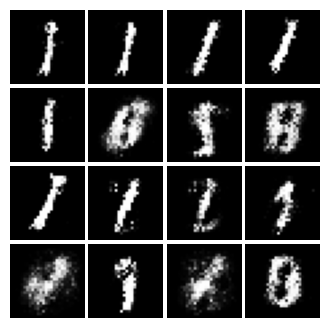
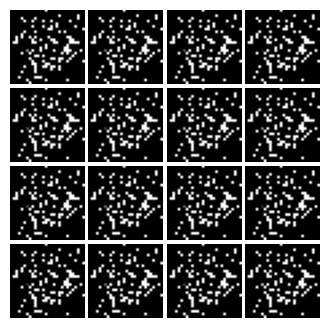

1. Image: with Logistic Loss we get some shape of the numbers, they might remember us for numbers
2. Image: with Vanilla the result is very bad there are not even shapes that could remember us for numbers it is a complete mess

Both of the images are after 5 epochs

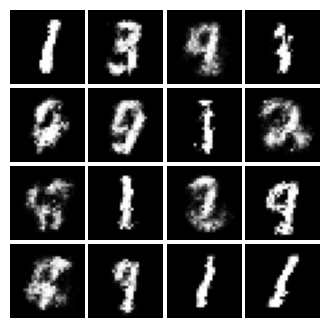
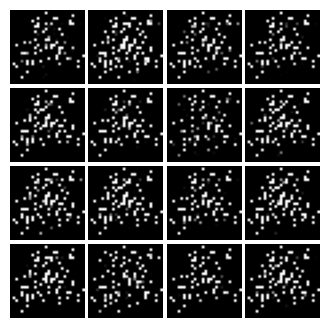

1. Image: with Logistic Loss the numbers are still noisy but we can recognize some of the numbers
2. Image: with Vanilla the numbers are a mess we still not recognize anything but there are less random white pixels

Both of the images are after 10 epochs. We also recognize that the Logistic Loss is way more faster than Vanilla

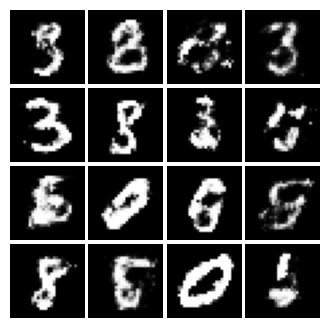
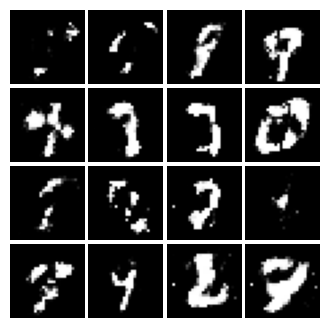

1. Image: Logistic Loss gave us recognizeable numbers in a really good quality it looks more stable and the generated random numbers are varied
2. Image: Vanilla's numbers are still barely recognizeable but now we recognize some of them we also noticed that Vanilla is a little bit unstable and it might have a repetitive pattern

Both of the images were taken after 50 epochs

Why is the output different for both cases?

Vanilla uses BCE loss + sigmoid and there is a bigger chance for the vanishing gradient problem in this model. If the discriminator is too good at distinguishing real and generated images then there is almost no gradient feedback it can lead to unstable training.

Logistic Loss works directly on logits so it will be more stable and providing better more useful gradients even when the discriminator performs well.



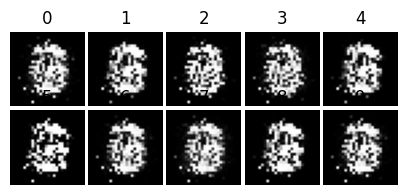
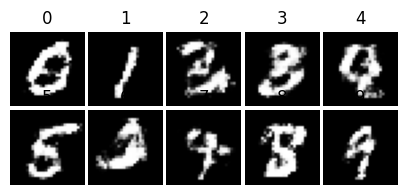
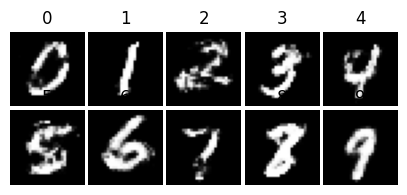

The first imae is from the frist epoch the send is from the 25th epoch and the last image is from the 50th epoch.
As we can see the model is a little bit unstable because on the second image we have more of one number but for the 50th epoch we got all of the numbers in really good quality and all of them recognizable. It is better than Vanilla or Logistic loss. It helped that we determined the numbers from 0 to 9.